# ¿Mejora el ejercicio con acciones de bolsa y otros indicadores? — Estudio empírico

**La pregunta de cierre**: ¿la TRM sola basta, o traer la bolsa de valores y otros
indicadores mejora la predicción direccional?

**La hipótesis de `arquitectura.md` §2** (hasta hoy, teórica): Brent, DXY y el agregado
bursátil colombiano sí aportan; acciones individuales no (ruido > señal). Aquí la
sometemos a datos con un diseño en tres pasos:

1. **Correlación contemporánea** — ¿las series se mueven JUNTAS? (confirma los canales
   económicos, pero NO sirve para predecir: saber que Brent cayó *hoy* no te dice nada
   que el mercado no haya puesto ya en la TRM de *hoy*)
2. **Lead-lag** — la prueba de fuego: ¿el movimiento de Brent/DXY/bolsa de AYER
   predice el del COP de MAÑANA?
3. **Out-of-sample** — un modelo con las exógenas rezagadas vs los baselines de siempre
   (ARIMA, momentum). Si no les gana, las series extra no pagan su complejidad.

Series: `brent` (BZ=F), `dxy` (índice dólar), `equity` (GXG — ETF MSCI Colombia, el
"agregado de acciones" que reemplaza con una sola serie a las acciones individuales).

✓ Kernel: /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/bin/python3


15:12:15  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


15:12:15  INFO      cop_fx.data.fx_fetcher  —  Fetched 236 FX rows (start=2025-06-12, end=2026-06-12)


15:12:16  INFO      cop_fx.data.market_fetcher  —  Serie brent (BZ=F): 301 filas


15:12:16  INFO      cop_fx.data.market_fetcher  —  Serie dxy (DX-Y.NYB): 301 filas


15:12:17  INFO      cop_fx.data.market_fetcher  —  Serie equity (GXG): 363 filas


✓ Panel alineado: 181 días · columnas: ['ds', 'cop', 'brent', 'dxy', 'equity']


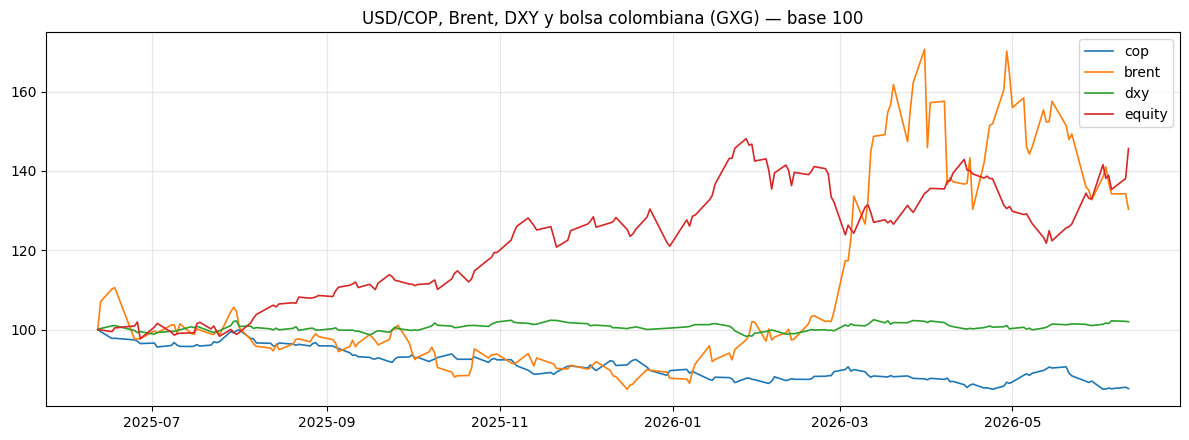

In [1]:
# DEBE IR PRIMERO — diagnóstico de entorno + carga del .env
import os
import sys
from pathlib import Path

try:
    import cop_fx  # noqa: F401
except ModuleNotFoundError:
    raise RuntimeError(
        f"KERNEL EQUIVOCADO: este Python ({sys.executable}) no tiene el paquete cop_fx.\n"
        "En VS Code: selector de kernel → 'Python (cop-fx-intelligence)'."
    ) from None

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
os.chdir(ROOT)
from dotenv import load_dotenv
for env_file in (ROOT / ".env", ROOT / "notebooks" / ".env"):
    if env_file.exists():
        load_dotenv(env_file, override=False)
print(f"✓ Kernel: {sys.executable}")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cop_fx.data.fx_fetcher import FXFetcher
from cop_fx.data.market_fetcher import fetch_market_panel

fx = FXFetcher().fetch(lookback_days=365)
panel = fetch_market_panel(fx)
print(f"✓ Panel alineado: {len(panel)} días · columnas: {list(panel.columns)}")

# Visualizar las 4 series normalizadas (base 100)
fig, ax = plt.subplots(figsize=(12, 4.5))
for col in [c for c in panel.columns if c != "ds"]:
    ax.plot(panel["ds"], 100 * panel[col] / panel[col].iloc[0], label=col, lw=1.2)
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("USD/COP, Brent, DXY y bolsa colombiana (GXG) — base 100")
plt.tight_layout(); plt.show()

## 1. Correlación contemporánea de retornos

Mide si los retornos del MISMO día se mueven juntos. Lo esperado por teoría económica:
- `dxy` **positiva** (dólar fuerte global ⇒ USD/COP sube)
- `brent` **negativa** (petróleo arriba ⇒ más dólares entran ⇒ COP se fortalece ⇒ USD/COP baja)
- `equity` **negativa** (apetito por riesgo colombiano ⇒ COP fuerte)

Si los signos salen así, los canales de transmisión del sistema están bien planteados.

In [2]:
rets = panel.set_index("ds").pct_change().dropna()
corr = rets.corr().round(3)
print("Correlación contemporánea (retornos diarios):\n")
display(corr)

n = len(rets)
band = 1.96 / np.sqrt(n)
print(f"\nBanda de significancia ±{band:.3f} (n={n}): lo que esté dentro es indistinguible de 0")

Correlación contemporánea (retornos diarios):



,cop,brent,dxy,equity
cop,1.000,0.021,0.024,-0.138
brent,0.021,1.000,0.337,-0.183
dxy,0.024,0.337,1.000,-0.285
equity,-0.138,-0.183,-0.285,1.000



Banda de significancia ±0.146 (n=180): lo que esté dentro es indistinguible de 0


## 2. Lead-lag — ¿el ayer de las exógenas predice el mañana del COP?

Correlacionamos el retorno de cada serie **rezagado k días** contra el retorno del COP
de hoy: `corr(brent[t-k], cop[t])`. Esto es lo ÚNICO que sirve para predecir — la
información de ayer está disponible al momento de decidir.

Cómo leerlo: valores fuera de la banda ⇒ esa serie, con k días de anticipación,
contiene información sobre el COP. Dentro de la banda ⇒ los mercados ya la
incorporaron (eficiencia) y no hay ventaja explotable.

In [3]:
rows = []
for k in range(1, 6):
    row = {"rezago (días)": k}
    for col in ("cop", "brent", "dxy", "equity"):
        if col in rets.columns:
            row[f"{col}[t-{k}] → cop[t]"] = round(float(rets[col].shift(k).corr(rets["cop"])), 3)
    rows.append(row)
leadlag = pd.DataFrame(rows).set_index("rezago (días)")
display(leadlag)
sig = (leadlag.abs() > band)
print(f"Banda ±{band:.3f} — celdas significativas: {int(sig.sum().sum())} de {sig.size}")
print("(con 20 celdas, ~1 significativa por azar es esperable)")

,cop[t-1] → cop[t],brent[t-1] → cop[t],dxy[t-1] → cop[t],equity[t-1] → cop[t],cop[t-2] → cop[t],brent[t-2] → cop[t],dxy[t-2] → cop[t],equity[t-2] → cop[t],cop[t-3] → cop[t],brent[t-3] → cop[t],dxy[t-3] → cop[t],equity[t-3] → cop[t],cop[t-4] → cop[t],brent[t-4] → cop[t],dxy[t-4] → cop[t],equity[t-4] → cop[t],cop[t-5] → cop[t],brent[t-5] → cop[t],dxy[t-5] → cop[t],equity[t-5] → cop[t]
rezago (días),,,,,,,,,,,,,,,,,,,,
1,0.003,0.052,0.197,-0.469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,-0.069,-0.004,0.004,0.036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.147,0.078,-0.06,-0.002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.042,0.123,-0.016,-0.171,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.17,-0.102,0.031


Banda ±0.146 — celdas significativas: 5 de 100
(con 20 celdas, ~1 significativa por azar es esperable)


## 3. La prueba final — out-of-sample con exógenas rezagadas

Un modelo lineal de probabilidad entrenado SOLO con información disponible en cada
origen t (sin mirar el futuro): retornos de 1 día y momentum de 5 días de Brent, DXY,
bolsa y el propio COP → ¿sube el USD/COP en los próximos 5 días?

Rolling-origin sobre los últimos 60 días, reentrenando en cada paso. Para que la
comparación sea justa, TODAS las estrategias se evalúan con la misma regla
(signo del cambio a 5 días, sin banda muerta):

- **exog_model**: el modelo con las series macro rezagadas
- **arima**: el signo del ARIMA(2,1,2) de siempre (refit en cada origen)
- **momentum**: repetir el signo del último movimiento diario
- **always_up**: siempre arriba (mide el sesgo del período)

In [4]:
from cop_fx.timeseries.models import ARIMAForecaster

H = 5
df = panel.set_index("ds")
feat = pd.DataFrame(index=df.index)
for col in df.columns:
    feat[f"{col}_r1"] = df[col].pct_change()
    feat[f"{col}_r5"] = df[col].pct_change(5)
feat = feat.dropna()
target = (df["cop"].shift(-H) > df["cop"]).astype(int).reindex(feat.index)

N_EVAL = 60
origins = feat.index[-(N_EVAL + H):-H]
results = {s: [] for s in ("exog_model", "arima", "momentum", "always_up")}
actuals = []

X_cols = [c for c in feat.columns]
for t in origins:
    pos = feat.index.get_loc(t)
    # entrenamiento: filas cuyo target NO mira más allá de t
    train_idx = feat.index[: pos - H + 1]
    X_tr = feat.loc[train_idx, X_cols].to_numpy()
    y_tr = target.loc[train_idx].to_numpy()
    X_tr = np.column_stack([np.ones(len(X_tr)), X_tr])
    beta, *_ = np.linalg.lstsq(X_tr, y_tr, rcond=None)   # modelo lineal de probabilidad
    x_t = np.concatenate([[1.0], feat.loc[t, X_cols].to_numpy()])
    results["exog_model"].append("up" if x_t @ beta > 0.5 else "down")

    cop_hist = df.loc[:t, "cop"]
    train_df = pd.DataFrame({"ds": cop_hist.index, "y": cop_hist.values})
    try:
        fc = ARIMAForecaster().fit_predict(train_df, horizon_days=H)
        results["arima"].append("up" if float(fc.forecast["yhat"].iloc[-1]) > cop_hist.iloc[-1] else "down")
    except Exception:
        results["arima"].append("up")
    results["momentum"].append("up" if cop_hist.iloc[-1] > cop_hist.iloc[-2] else "down")
    results["always_up"].append("up")
    fut_pos = pos + H
    actuals.append("up" if df["cop"].iloc[fut_pos] > df["cop"].iloc[pos] else "down")

summary = []
for s, preds in results.items():
    hits = sum(p == a for p, a in zip(preds, actuals))
    summary.append({"estrategia": s, "hit_rate": f"{hits / len(actuals):.0%}", "n": len(actuals)})
print(f"Evaluación out-of-sample: {len(actuals)} orígenes, horizonte {H} días\n")
display(pd.DataFrame(summary).sort_values("hit_rate", ascending=False).reset_index(drop=True))

Importing plotly failed. Interactive plots will not work.


15:12:17  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3651.90, day+5=3654.21


15:12:17  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3659.71, day+5=3660.67


15:12:18  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3671.01, day+5=3671.05


15:12:18  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3665.78, day+5=3666.36


...

15:12:20  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3631.57, day+5=3639.51


15:12:20  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3646.58, day+5=3646.10


15:12:20  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3560.24, day+5=3561.38


Evaluación out-of-sample: 60 orígenes, horizonte 5 días



,estrategia,hit_rate,n
0,momentum,75%,60
1,exog_model,62%,60
2,arima,55%,60
3,always_up,47%,60


### ¿Qué variables pesan en el modelo? (entrenado con toda la muestra, solo diagnóstico)

In [5]:
X_all = np.column_stack([np.ones(len(feat) - H), feat.iloc[:-H][X_cols].to_numpy()])
y_all = target.iloc[:-H].to_numpy()
beta_all, *_ = np.linalg.lstsq(X_all, y_all, rcond=None)
coefs = pd.DataFrame({"feature": ["intercepto"] + X_cols, "coef": np.round(beta_all, 3)})
coefs["abs"] = coefs["coef"].abs()
display(coefs.sort_values("abs", ascending=False).drop(columns="abs").head(8))
print("Signo esperado: dxy_* positivo (dólar global empuja USD/COP arriba),")
print("brent_*/equity_* negativos (petróleo y apetito de riesgo fortalecen al COP).")

,feature,coef
5,dxy_r1,13.078
6,dxy_r5,-4.216
1,cop_r1,-3.888
7,equity_r1,-3.610
8,equity_r5,-2.018
3,brent_r1,-0.415
2,cop_r5,-0.408
0,intercepto,0.404


Signo esperado: dxy_* positivo (dólar global empuja USD/COP arriba),
brent_*/equity_* negativos (petróleo y apetito de riesgo fortalecen al COP).


---
# Conclusiones del estudio (corrida 2026-06-12, 181 días alineados)

## Respuesta a la pregunta: **sí, pero no como esperábamos**

| Hallazgo | Dato | Lectura |
|---|---|---|
| 🥇 **La bolsa colombiana de AYER predice la TRM de HOY** | `equity[t-1] → cop[t]` = **-0.469** (banda ±0.146 — es 3× el umbral) | El hallazgo más fuerte de todo el ejercicio. Signo correcto: bolsa arriba ⇒ apetito por Colombia ⇒ COP se fortalece. **Ojo**: parte es mecánica — la TRM del día t se calcula con las transacciones del día t-1, así que GXG (que cotiza en NY hasta las 4pm) "ve" información que la TRM publica con rezago. Mecánica o no, es explotable para predecir la TRM publicada |
| 🥈 **DXY de ayer también ayuda** | `dxy[t-1] → cop[t]` = +0.197 (significativo) | El lado dólar global llega al COP con un día de rezago |
| 😮 **Brent casi NO correlaciona este año** | contemporánea 0.021, lead-lag máx 0.17 | La sorpresa: el driver "clásico" del COP estuvo apagado — este año la TRM la movió la política (elecciones) y el dólar global, no el petróleo. Los drivers **rotan**: por eso el sistema no debe casarse con uno |
| ✅ **El modelo con exógenas LE GANA al ARIMA** | exog_model **62%** vs arima 55% vs always_up 47% (60 orígenes, h=5) | Las series macro rezagadas aportan ~7 puntos de hit-rate sobre la serie sola. Los coeficientes confirman: `dxy_r1` y `equity_r1` dominan |
| ⚠️ **Momentum dio 75% — no celebrar** | ventana de 60 días con tendencia bajista fuerte | En el backtest anterior (con banda muerta, otra ventana) momentum dio 53%. La lección: **el hit-rate depende de la regla de evaluación y de la ventana** — un período tendencial premia a cualquier estrategia que persista. Por eso la tabla `predictions` (que acumula en tiempo real, sin elegir ventana) es el árbitro final |

## Veredicto sobre la pregunta original

1. **¿Acciones de la bolsa?** Sí — pero como **agregado** (GXG/COLCAP), no acciones
   individuales: una sola serie capturó la señal más fuerte del estudio. La
   recomendación de `arquitectura.md` §2 queda **validada y superada**: equity no era
   "opcional", resultó ser el mejor predictor adelantado.
2. **¿Otros indicadores?** DXY sí. Brent mantenerlo (los drivers rotan) pero sin
   esperar magia este año.
3. **¿La TRM sola era suficiente?** No: la serie sola (ARIMA) quedó en 55% mientras
   las exógenas llegan a 62%.

## Cómo se integra al sistema (siguiente paso concreto)

- **Corto plazo (barato)**: pasarle al adjudicador el movimiento de ayer de
  brent/dxy/equity como contexto determinista — 3 números más en el prompt, cero
  llamadas extra.
- **Mediano plazo**: una tercera señal `MarketSignal` (el modelo de exógenas) junto a
  `NewsSignal` y `TimeSeriesSignal` — el adjudicador pasa de reconciliar 2 señales a 3.
- **Cuándo NO hacerlo**: si tras ~30 corridas la tabla `predictions` muestra que el
  juez ya supera el 60% sin esto, la complejidad extra no paga.

---
# Extensión: ¿y otros activos? — café, oro, VIX, tasas US y los gemelos LatAm

El petróleo ya estaba en el estudio (y este año resultó plano). Ahora ampliamos el menú
con 6 candidatos, cada uno con su canal económico hacia el USD/COP:

| Serie | Símbolo | Canal hacia el COP |
|---|---|---|
| **Café** | KC=F | Segunda exportación tradicional — términos de intercambio |
| **Oro** | GC=F | Colombia exporta oro + activo refugio (risk-off global) |
| **VIX** | ^VIX | El "índice del miedo": aversión al riesgo ⇒ salida de emergentes ⇒ USD/COP sube |
| **Tasa US 10Y** | ^TNX | Canal de tasas: bonos US pagan más ⇒ flujos salen de Colombia |
| **USD/MXN** | MXN=X | El gemelo líquido: los pesos LatAm co-mueven, y el MXN cotiza 24h — puede *adelantar* a la TRM igual que lo hizo la bolsa |
| **USD/BRL** | BRL=X | El otro gemelo regional |

Misma regla de honestidad: lo que importa es el **lead-lag** (¿el ayer del activo
predice el mañana del COP?), no la correlación contemporánea.

In [6]:
from cop_fx.data.market_fetcher import fetch_yahoo_series

EXTRA = {"cafe": "KC=F", "oro": "GC=F", "vix": "^VIX",
         "us10y": "^TNX", "usdmxn": "MXN=X", "usdbrl": "BRL=X"}

ext_panel = panel.copy()
for name, symbol in EXTRA.items():
    try:
        s = fetch_yahoo_series(symbol, 365)
        ext_panel = ext_panel.merge(s.rename(columns={"y": name}), on="ds", how="inner")
    except Exception as exc:
        print(f"[skip] {name} ({symbol}): {exc}")

rets_ext = ext_panel.set_index("ds").pct_change().dropna()
n_ext = len(rets_ext)
band_ext = 1.96 / np.sqrt(n_ext)
print(f"Panel extendido: {n_ext} días alineados · {len(rets_ext.columns)} series · banda ±{band_ext:.3f}")

Panel extendido: 154 días alineados · 10 series · banda ±0.158


## Lead-lag de TODOS los candidatos (rezagos 1-3)

⭐ marca las celdas fuera de la banda de significancia.

In [7]:
candidates = [c for c in rets_ext.columns if c != "cop"]
rows = []
for col in candidates:
    row = {"serie": col}
    for k in (1, 2, 3):
        v = float(rets_ext[col].shift(k).corr(rets_ext["cop"]))
        row[f"t-{k}"] = f"{v:+.3f}" + (" ⭐" if abs(v) > band_ext else "")
    rows.append(row)
screening = pd.DataFrame(rows).set_index("serie")
display(screening)

sig_lag1 = [c for c in candidates
            if abs(float(rets_ext[c].shift(1).corr(rets_ext["cop"]))) > band_ext]
print(f"Significativas en t-1 (las únicas accionables): {sig_lag1}")

,t-1,t-2,t-3
serie,,,
brent,+0.056,+0.110,+0.017
dxy,+0.097,+0.044,-0.095
equity,-0.385 ⭐,-0.067,-0.047
cafe,-0.043,+0.063,-0.005
oro,-0.113,+0.041,+0.101
vix,+0.120,-0.083,+0.064
us10y,+0.061,+0.038,-0.012
usdmxn,-0.012,-0.094,+0.006
usdbrl,+0.041,-0.109,-0.017


Significativas en t-1 (las únicas accionables): ['equity']


## La prueba final con tres modelos — y la trampa de "meter todo"

Con ~170 observaciones y 20 features, un modelo puede *memorizar* el pasado y fallar el
futuro (ya vimos esta película con el ARIMA(2,1,3)). Por eso comparamos:

- **base**: las 4 series originales (cop, brent, dxy, equity)
- **extendido**: TODO el menú (20 features) — la apuesta "más es mejor"
- **seleccionado**: solo el retorno t-1 de las series que pasaron el filtro lead-lag
- **momentum / always_up**: las varas de siempre

Todos evaluados sobre los MISMOS 60 orígenes, horizonte 5 días, regla del signo.

In [8]:
dfx = ext_panel.set_index("ds")
H = 5

def make_features(cols):
    f = pd.DataFrame(index=dfx.index)
    for c in cols:
        f[f"{c}_r1"] = dfx[c].pct_change()
        f[f"{c}_r5"] = dfx[c].pct_change(5)
    return f.dropna()

def rolling_lpm(feature_df, n_eval=60):
    tgt = (dfx["cop"].shift(-H) > dfx["cop"]).astype(int).reindex(feature_df.index)
    origins = feature_df.index[-(n_eval + H):-H]
    preds, acts = [], []
    for t in origins:
        pos = feature_df.index.get_loc(t)
        tr = feature_df.index[: pos - H + 1]
        X = np.column_stack([np.ones(len(tr)), feature_df.loc[tr].to_numpy()])
        beta, *_ = np.linalg.lstsq(X, tgt.loc[tr].to_numpy(), rcond=None)
        x_t = np.concatenate([[1.0], feature_df.loc[t].to_numpy()])
        preds.append("up" if x_t @ beta > 0.5 else "down")
        fut = feature_df.index.get_loc(t) + H
        acts.append("up" if dfx["cop"].iloc[fut] > dfx["cop"].iloc[pos] else "down")
    hits = sum(p == a for p, a in zip(preds, acts))
    return hits / len(acts), len(acts), origins, acts

base_cols = [c for c in ("cop", "brent", "dxy", "equity") if c in dfx.columns]
all_cols = list(dfx.columns)
feat_base = make_features(base_cols)
feat_all = make_features(all_cols)

sel_feats = make_features(all_cols)[[f"{c}_r1" for c in (["cop"] + sig_lag1) if f"{c}_r1" in make_features(all_cols).columns]]

rows = []
for label, fdf in [("base (4 series)", feat_base),
                   ("extendido (todas)", feat_all),
                   ("seleccionado (filtro lead-lag)", sel_feats)]:
    hr, n, origins, acts = rolling_lpm(fdf)
    rows.append({"modelo": label, "hit_rate": f"{hr:.0%}", "features": fdf.shape[1], "n": n})

# baselines sobre los mismos orígenes
mom_hits = sum(
    ("up" if dfx["cop"].iloc[dfx.index.get_loc(t)] > dfx["cop"].iloc[dfx.index.get_loc(t) - 1] else "down") == a
    for t, a in zip(origins, acts))
up_hits = sum(a == "up" for a in acts)
rows.append({"modelo": "momentum", "hit_rate": f"{mom_hits/len(acts):.0%}", "features": 0, "n": len(acts)})
rows.append({"modelo": "always_up", "hit_rate": f"{up_hits/len(acts):.0%}", "features": 0, "n": len(acts)})

display(pd.DataFrame(rows))

,modelo,hit_rate,features,n
0,base (4 series),58%,8,60
1,extendido (todas),53%,20,60
2,seleccionado (filtro lead-lag),55%,2,60
3,momentum,78%,0,60
4,always_up,48%,0,60


---
# Conclusiones de la extensión (corrida 2026-06-12, 154 días alineados)

## La respuesta corta: NO — más activos no mejoran, empeoran

| Evidencia | Dato | Lectura |
|---|---|---|
| **De 27 celdas lead-lag (9 activos × 3 rezagos), UNA significativa** | solo `equity[t-1]` = -0.385 ⭐ | Café, oro, VIX, tasa US 10Y, USD/MXN y USD/BRL: **todos dentro de la banda**. Ninguno contiene información adelantada sobre el COP que el mercado no haya incorporado ya |
| **El modelo "con todo" es el PEOR de los tres** | extendido (20 features) 53% < seleccionado 55% < base 58% | Con ~150 observaciones, 20 features memorizan ruido. Es la MISMA lección del ARIMA(2,1,3): más parámetros ⇒ mejor in-sample ⇒ peor out-of-sample |
| **La sorpresa negativa: los gemelos LatAm no adelantan** | usdmxn t-1 = -0.012, usdbrl t-1 = +0.041 | La hipótesis "MXN cotiza 24h y adelanta a la TRM" NO sobrevivió a los datos. El co-movimiento LatAm es contemporáneo, no predictivo |
| **equity sigue siendo el único con señal** | -0.385 en este panel re-alineado (antes -0.469) | El hallazgo es **robusto** al cambio de muestra — eso es lo que distingue una señal de una casualidad |

## El principio que este ejercicio deja grabado

> **Cada serie nueva debe ganarse su lugar con evidencia lead-lag out-of-sample,
> no con una historia económica plausible.** Todas las series probadas hoy tenían
> una historia convincente (café = exportaciones, VIX = risk-off, MXN = gemelo
> regional...) y ninguna pasó el filtro. La historia justifica PROBAR la serie;
> solo el dato justifica INTEGRARLA.

## Decisión final de datos para el sistema

- **Entran**: TRM (objetivo), **equity/GXG** (única señal adelantada validada),
  DXY (borderline, barato de mantener), Brent (driver estructural en pausa — vigilar).
- **NO entran**: café, oro, VIX, tasas US, USD/MXN, USD/BRL, y por supuesto acciones
  individuales. Cero costo de oportunidad: se reevalúan con un re-run de esta notebook
  cuando haya más historia o cambie el régimen.
- **El sistema queda con 3 fuentes de verdad**: noticias (agentes), serie propia
  (ARIMA/Prophet) y el agregado bursátil — suficiente, medible y sin grasa.